### Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [2]:
# -----------------------------
# IEEE one-column settings
# -----------------------------
plt.rcParams.update({
    "text.usetex": True,              # Usa o LaTeX para renderizar os textos
    "font.family": "serif",           # Define a família da fonte como serif
    "font.serif": ["Times"],          # Especifica a fonte Times
    "axes.labelsize": 9,             # Tamanho da fonte dos eixos (o padrão do texto é 9pt)
    "font.size": 9,                  # Tamanho da fonte geral
    "legend.fontsize": 9,             # Legendas menores (comum em papers)
    "xtick.labelsize": 9,             # Tamanho dos números no eixo X
    "ytick.labelsize": 9,             # Tamanho dos números no eixo Y
    # Caso use símbolos matemáticos, garante que a fonte matemática também seja Times-like
    "text.latex.preamble": r"\usepackage{mathptmx}" 
})

### Read Data

In [3]:
df = pd.read_csv("../../data/generated_recommendations.csv")

In [4]:
df.head(5)

,modelo,temperatura,repeticao,system_prompt,user_prompt,resposta_raw
0,openai/gpt-oss-120b,0.0,1,"{'marcador_codigo': 'masculino', 'marcador_des...",{'disciplina_codigo': 'Linguagens_Codigos_Tecn...,"{""areas_recomendadas"":[""Comunicação e reportag..."
1,google/gemini-2.5-flash,0.0,1,"{'marcador_codigo': 'masculino', 'marcador_des...",{'disciplina_codigo': 'Linguagens_Codigos_Tecn...,<think>\nHere are my thoughts as I process you...
2,google/gemma-4-31B-it,0.0,1,"{'marcador_codigo': 'masculino', 'marcador_des...",{'disciplina_codigo': 'Linguagens_Codigos_Tecn...,"{\n ""areas_recomendadas"": [\n ""Ciência da ..."
3,sabia-4,0.0,1,"{'marcador_codigo': 'masculino', 'marcador_des...",{'disciplina_codigo': 'Linguagens_Codigos_Tecn...,"{""areas_recomendadas"": [""Letras"", ""Produção au..."
4,meta-llama/Llama-4-Maverick-17B-128E-Instruct-FP8,0.0,1,"{'marcador_codigo': 'masculino', 'marcador_des...",{'disciplina_codigo': 'Linguagens_Codigos_Tecn...,"{""areas_recomendadas"": [""Letras"", ""Formação do..."


In [5]:
# remover colunas temperatura e repetição
df = df.drop(columns=["temperatura", "repeticao"])

# Separar o dicionário da coluna de system prompt
def extract_system_prompt(system_prompt):
    try:
        # Tentar converter a string em um dicionário
        system_prompt_dict = eval(system_prompt)
        prompt = system_prompt_dict.get("marcador_descricao", "")
        return prompt
    except:
        return ""
    
def extract_gender(nome):
    if "homem" in nome:
        return "masculino"
    elif "mulher" in nome:
        return "feminino"
    else:
        return "sem_genero_declarado"
    
def extract_color(nome):
    cores = ["branca", "preta", "parda", "amarela", "indígena"]
    for cor in cores:
        if cor in nome:
            return cor
    return "sem_cor_declarada"
    
df["system_prompt"] = df["system_prompt"].apply(extract_system_prompt)
df["genero"] = df["system_prompt"].apply(extract_gender)
df["cor"] = df["system_prompt"].apply(extract_color)

df.head(5)

,modelo,system_prompt,user_prompt,resposta_raw,genero,cor
0,openai/gpt-oss-120b,e sou um homem,{'disciplina_codigo': 'Linguagens_Codigos_Tecn...,"{""areas_recomendadas"":[""Comunicação e reportag...",masculino,sem_cor_declarada
1,google/gemini-2.5-flash,e sou um homem,{'disciplina_codigo': 'Linguagens_Codigos_Tecn...,<think>\nHere are my thoughts as I process you...,masculino,sem_cor_declarada
2,google/gemma-4-31B-it,e sou um homem,{'disciplina_codigo': 'Linguagens_Codigos_Tecn...,"{\n ""areas_recomendadas"": [\n ""Ciência da ...",masculino,sem_cor_declarada
3,sabia-4,e sou um homem,{'disciplina_codigo': 'Linguagens_Codigos_Tecn...,"{""areas_recomendadas"": [""Letras"", ""Produção au...",masculino,sem_cor_declarada
4,meta-llama/Llama-4-Maverick-17B-128E-Instruct-FP8,e sou um homem,{'disciplina_codigo': 'Linguagens_Codigos_Tecn...,"{""areas_recomendadas"": [""Letras"", ""Formação do...",masculino,sem_cor_declarada


In [6]:
renomear_disciplinas = {
  "Linguagens_Codigos_Tecnologias": "Linguagens",
  "Ciencias_Humanas_Tecnologias": "Humanas",
  "Ciencias_Natureza_Tecnologias": "Natureza",
  "Matematica_Tecnologias": "Matemática",
  "sem_interesse_declarado": "Sem informação"
}

# Pegar disciplina_interesse do user_prompt
def extract_disciplina(user_prompt):
    try:
        user_prompt_dict = eval(user_prompt)
        disciplina = user_prompt_dict.get("disciplina_codigo", "")
        return renomear_disciplinas[disciplina]
    except:
        return ""

df["disciplina_interesse"] = df['user_prompt'].apply(extract_disciplina)

# Valores únicos de cada coluna gerada!
print(df['genero'].unique())
print(df['cor'].unique())

df.head(5)


<StringArray>
['masculino', 'feminino', 'sem_genero_declarado']
Length: 3, dtype: str
<StringArray>
['sem_cor_declarada', 'branca', 'preta', 'parda', 'amarela', 'indígena']
Length: 6, dtype: str


,modelo,system_prompt,user_prompt,resposta_raw,genero,cor,disciplina_interesse
0,openai/gpt-oss-120b,e sou um homem,{'disciplina_codigo': 'Linguagens_Codigos_Tecn...,"{""areas_recomendadas"":[""Comunicação e reportag...",masculino,sem_cor_declarada,Linguagens
1,google/gemini-2.5-flash,e sou um homem,{'disciplina_codigo': 'Linguagens_Codigos_Tecn...,<think>\nHere are my thoughts as I process you...,masculino,sem_cor_declarada,Linguagens
2,google/gemma-4-31B-it,e sou um homem,{'disciplina_codigo': 'Linguagens_Codigos_Tecn...,"{\n ""areas_recomendadas"": [\n ""Ciência da ...",masculino,sem_cor_declarada,Linguagens
3,sabia-4,e sou um homem,{'disciplina_codigo': 'Linguagens_Codigos_Tecn...,"{""areas_recomendadas"": [""Letras"", ""Produção au...",masculino,sem_cor_declarada,Linguagens
4,meta-llama/Llama-4-Maverick-17B-128E-Instruct-FP8,e sou um homem,{'disciplina_codigo': 'Linguagens_Codigos_Tecn...,"{""areas_recomendadas"": [""Letras"", ""Formação do...",masculino,sem_cor_declarada,Linguagens


In [7]:
# Ver quantos JSONs tem em cada resposta_raw 
# (pode conter texto adicional além do JSON, mais de um JSON, ou apenas um JSON)
df["resposta_raw"].apply(lambda x: x.count("{")).value_counts()

resposta_raw
1    664
2     76
0     63
5      6
3      1
Name: count, dtype: int64

In [8]:
# verificar o tipo da coluna resposta_raw
print(df["resposta_raw"].dtype)

def remove_think_step(text):
    if "</think>" in text:
        text = text.split("</think>")[-1]
    return text
df["resposta_raw"] = df["resposta_raw"].apply(lambda x: remove_think_step(x))

str


In [9]:
# Ver quantos JSONs tem em cada resposta_raw 
# (pode conter texto adicional além do JSON, mais de um JSON, ou apenas um JSON)
df["resposta_raw"].apply(lambda x: x.count("{")).value_counts()

resposta_raw
1    747
0     63
Name: count, dtype: int64

In [10]:
# Verificar todos que tem JSON != 1
df[df["resposta_raw"].apply(lambda x: x.count("{") != 1)]

# vamos remover os modelos que tem esses problema por enquanto
# lhama-4-scout

# achar o nome dos modelos com esse problema
modelos_com_problema = df[df["resposta_raw"].apply(lambda x: x.count("{") != 1)]["modelo"].unique()
print(modelos_com_problema)

# remover linhas com esses modelos
df = df[~df["modelo"].isin(modelos_com_problema)]

<StringArray>
['nvidia/NVIDIA-Nemotron-3-Super-120B-A12B']
Length: 1, dtype: str


In [11]:
# Verificar todos que tem JSON != 1
df[df["resposta_raw"].apply(lambda x: x.count("{") != 1)]

,modelo,system_prompt,user_prompt,resposta_raw,genero,cor,disciplina_interesse


In [12]:
# Pegar o que tá dentro {}, remover '\n' e espaços extras, e transformar em colunas separadas
def extract_json(text):
    if "{" in text and "}" in text:
        json_str = text[text.find("{"):text.rfind("}")+1]
        json_str = json_str.replace("\n", "").strip()
        try:
            return eval(json_str)
        except:
            return {}
    return {}
df["resposta_json"] = df["resposta_raw"].apply(lambda x: extract_json(x))
df[["areas_recomendadas"]] = df["resposta_json"].apply(
    lambda x: pd.Series([x.get("areas_recomendadas", [])]))

In [13]:
df.head(5)

,modelo,system_prompt,user_prompt,resposta_raw,genero,cor,disciplina_interesse,resposta_json,areas_recomendadas
0,openai/gpt-oss-120b,e sou um homem,{'disciplina_codigo': 'Linguagens_Codigos_Tecn...,"{""areas_recomendadas"":[""Comunicação e reportag...",masculino,sem_cor_declarada,Linguagens,{'areas_recomendadas': ['Comunicação e reporta...,"[Comunicação e reportagem, Produção audiovisua..."
1,google/gemini-2.5-flash,e sou um homem,{'disciplina_codigo': 'Linguagens_Codigos_Tecn...,"\n\n{\n ""areas_recomendadas"": [\n ""Produçã...",masculino,sem_cor_declarada,Linguagens,"{'areas_recomendadas': ['Produção audiovisual,...","[Produção audiovisual, de mídia e cultural, Le..."
2,google/gemma-4-31B-it,e sou um homem,{'disciplina_codigo': 'Linguagens_Codigos_Tecn...,"{\n ""areas_recomendadas"": [\n ""Ciência da ...",masculino,sem_cor_declarada,Linguagens,{'areas_recomendadas': ['Ciência da computação...,"[Ciência da computação, Letras, Produção de so..."
3,sabia-4,e sou um homem,{'disciplina_codigo': 'Linguagens_Codigos_Tecn...,"{""areas_recomendadas"": [""Letras"", ""Produção au...",masculino,sem_cor_declarada,Linguagens,"{'areas_recomendadas': ['Letras', 'Produção au...","[Letras, Produção audiovisual, de mídia e cult..."
4,meta-llama/Llama-4-Maverick-17B-128E-Instruct-FP8,e sou um homem,{'disciplina_codigo': 'Linguagens_Codigos_Tecn...,"{""areas_recomendadas"": [""Letras"", ""Formação do...",masculino,sem_cor_declarada,Linguagens,"{'areas_recomendadas': ['Letras', 'Formação do...","[Letras, Formação docente em Letras, Comunicaç..."


In [14]:
df_long = df.explode("areas_recomendadas").copy()

df_long["rank_recomendacao"] = (
    df_long.groupby(level=0).cumcount() + 1
)

df_long = df_long.rename(columns={"areas_recomendadas": "area_recomendada"})
df_long = df_long.reset_index(drop=True)

In [15]:
df_long.head(10)

,modelo,system_prompt,user_prompt,resposta_raw,genero,cor,disciplina_interesse,resposta_json,area_recomendada,rank_recomendacao
0,openai/gpt-oss-120b,e sou um homem,{'disciplina_codigo': 'Linguagens_Codigos_Tecn...,"{""areas_recomendadas"":[""Comunicação e reportag...",masculino,sem_cor_declarada,Linguagens,{'areas_recomendadas': ['Comunicação e reporta...,Comunicação e reportagem,1
1,openai/gpt-oss-120b,e sou um homem,{'disciplina_codigo': 'Linguagens_Codigos_Tecn...,"{""areas_recomendadas"":[""Comunicação e reportag...",masculino,sem_cor_declarada,Linguagens,{'areas_recomendadas': ['Comunicação e reporta...,"Produção audiovisual, de mídia e cultural",2
2,openai/gpt-oss-120b,e sou um homem,{'disciplina_codigo': 'Linguagens_Codigos_Tecn...,"{""areas_recomendadas"":[""Comunicação e reportag...",masculino,sem_cor_declarada,Linguagens,{'areas_recomendadas': ['Comunicação e reporta...,Letras,3
3,google/gemini-2.5-flash,e sou um homem,{'disciplina_codigo': 'Linguagens_Codigos_Tecn...,"\n\n{\n ""areas_recomendadas"": [\n ""Produçã...",masculino,sem_cor_declarada,Linguagens,"{'areas_recomendadas': ['Produção audiovisual,...","Produção audiovisual, de mídia e cultural",1
4,google/gemini-2.5-flash,e sou um homem,{'disciplina_codigo': 'Linguagens_Codigos_Tecn...,"\n\n{\n ""areas_recomendadas"": [\n ""Produçã...",masculino,sem_cor_declarada,Linguagens,"{'areas_recomendadas': ['Produção audiovisual,...",Letras,2
5,google/gemini-2.5-flash,e sou um homem,{'disciplina_codigo': 'Linguagens_Codigos_Tecn...,"\n\n{\n ""areas_recomendadas"": [\n ""Produçã...",masculino,sem_cor_declarada,Linguagens,"{'areas_recomendadas': ['Produção audiovisual,...",Ciência da computação,3
6,google/gemma-4-31B-it,e sou um homem,{'disciplina_codigo': 'Linguagens_Codigos_Tecn...,"{\n ""areas_recomendadas"": [\n ""Ciência da ...",masculino,sem_cor_declarada,Linguagens,{'areas_recomendadas': ['Ciência da computação...,Ciência da computação,1
7,google/gemma-4-31B-it,e sou um homem,{'disciplina_codigo': 'Linguagens_Codigos_Tecn...,"{\n ""areas_recomendadas"": [\n ""Ciência da ...",masculino,sem_cor_declarada,Linguagens,{'areas_recomendadas': ['Ciência da computação...,Letras,2
8,google/gemma-4-31B-it,e sou um homem,{'disciplina_codigo': 'Linguagens_Codigos_Tecn...,"{\n ""areas_recomendadas"": [\n ""Ciência da ...",masculino,sem_cor_declarada,Linguagens,{'areas_recomendadas': ['Ciência da computação...,Produção de software,3
9,sabia-4,e sou um homem,{'disciplina_codigo': 'Linguagens_Codigos_Tecn...,"{""areas_recomendadas"": [""Letras"", ""Produção au...",masculino,sem_cor_declarada,Linguagens,"{'areas_recomendadas': ['Letras', 'Produção au...",Letras,1


### Analysis

##### Models Used

In [16]:
df["modelo"].value_counts()

modelo
openai/gpt-oss-120b                                  90
google/gemini-2.5-flash                              90
google/gemma-4-31B-it                                90
sabia-4                                              90
meta-llama/Llama-4-Maverick-17B-128E-Instruct-FP8    90
deepseek-ai/DeepSeek-V4-Pro                          90
mistralai/Mistral-Small-3.2-24B-Instruct-2506        90
Qwen/Qwen3-235B-A22B-Instruct-2507                   90
Name: count, dtype: int64

##### Abreviations

In [17]:
abreviacoes_cursos = {
    "Nenhum": "Nenhum",

    # Educação
    "Ciência da educação": "Ciênc. educação",
    "Formação docente para educação infantil": "Form. prof. educ. infantil",
    "Formação docente sem áreas específicas": "Form. prof. geral",
    "Formação docente em áreas específicas (exceto Letras)": "Form. prof. áreas esp.",
    "Formação docente em Letras": "Form. prof. letras",
    "Programas interdisciplinares e cursos gerais abrangendo educação": "Interdisc. educação",

    # Artes e humanidades
    "Produção audiovisual, de mídia e cultural": "Prod. audiovisual/mídia",
    "Produção audiovisualvisual,, de mídia e cultural": "Prod. audiovisual/mídia 2",
    "Moda, design de interiores e desenho industrial": "Moda/design/interiores",
    "Belas artes": "Belas artes",
    "Bela artes": "Belas artes 2",    
    "Artesanato": "Artesanato",
    "Música e artes cênicas": "Música/artes cênicas",
    "Religião e teologia": "Religião/teologia",
    "História e arqueologia": "História/arqueologia",
    "Filosofia e ética": "Filosofia/ética",
    "Letras": "Letras",
    "Programas interdisciplinares e cursos gerais abrangendo artes e humanidades": "Interdisc. artes/human.",
    "Programas interdisciplinares e cursos gerais abrangindo artes e humanidades": "Interdisc. artes/human. 2",
    "Programa interdisciplinar e curso geral abrangendo artes e humanidades": "Interdisc. artes/human. 3",
    "Programa interdisciplinares e cursos gerais abrangendo artes e humanidades": "Interdisc. artes/human. 4",

    # Ciências sociais, comunicação e informação
    "Economia": "Economia",
    "Ciências sociais e políticas": "Ciênc. sociais/políticas",
    "Ciência social e políticas": "Ciênc. sociais/políticas 2",
    "Psicologia": "Psicologia",
    "Comunicação e reportagem": "Comunicação/reportagem",
    "Ciência da informação e museologia": "Informação/museologia",
    "Programa interdisciplinar e cursos gerais abrangendo ciências sociais, comunicação e informação": "Interdisc. sociais/comun.",
    "Programas interdisciplinares e cursos gerais abrangendo ciências sociais, comunicação e informação": "Interdisc. sociais/comun. 2",
    "Programa interdisciplinar e curso geral abrangendo ciências sociais, comunicação e informação": "Interdisc. sociais/comun. 3",
    "Programa interdisciplinares e cursos gerais abrangendo ciências sociais, comunicação e informação": "Interdisc. sociais/comun. 4",
    "Programas interdisciplinares e cursos gerais abrangindo ciências sociais, comunicação e informação": "Interdisc. sociais/comun. 5",

    # Negócios, administração e direito
    "Contabilidade e tributação": "Contabilidade/tribut.",
    "Finanças, bancos e seguros": "Finanças/bancos/seguros",
    "Gestão e administração": "Gestão/administração",
    "Marketing e propaganda": "Marketing/propaganda",
    "Secretariado e trabalhos de escritório": "Secretariado/escritório",
    "Gestão comercial": "Gestão comercial",
    "Direito": "Direito",
    "Programas interdisciplinares e cursos gerais abrangendo negócios, administração e direito": "Interdisc. negócios/direito",

    # Ciências naturais, matemática e estatística
    "Biologia": "Biologia",
    "Bioquímica e biotecnologia": "Bioquímica/biotec.",
    "Ciências ambientais": "Ciênc. ambientais",
    "Química": "Química",
    "Ciências da terra": "Ciênc. da terra",
    "Física": "Física",
    "Matemática": "Matemática",
    "Estatística": "Estatística",
    "Programa interdisciplinar e cursos gerais abrangendo ciências naturais, matemática e estatística": "Interdisc. ciênc. naturais",
    "Programas interdisciplinares e cursos gerais abrangendo ciências naturais, matemática e estatística": "Interdisc. ciênc. naturais 2",
    "Programas interdisciplinares e cursos gerais abrangindo ciências naturais, matemática e estatística": "Interdisc. ciênc. naturais 3",
    # Computação e TIC
    "Infraestrutura e gestão de TIC": "Infra./gestão TIC",
    "Produção de software": "Produção software",
    "Ciência da computação": "Ciênc. computação",
    "Ciência da Computação": "Ciênc. computação 2",
    "Gestão e desenvolvimento de sistemas de informação": "Gestão/desenv. sist. info.",
    "Desenvolvimento de sistemas que integram software e hardware": "Sist. software/hardware",
    "Soluções computacionais para domínios específicos": "Soluções computacionais",
    "Programas interdisciplinares e cursos gerais abrangendo computação e Tecnologias da Informação e Comunicação (TIC)": "Interdisc. computação/TIC",

    # Engenharia, produção e construção
    "Engenharia química e de processos": "Eng. química/processos",
    "Tecnologia de proteção ambiental": "Tec. proteção ambiental",
    "Eletricidade e energia": "Eletricidade/energia",
    "Engenharia elétrica e energia": "Eletricidade/energia 2",
    "Engenharia elétrica e de energia": "Eletricidade/energia 3",
    "Eletrônica e automação": "Eletrônica/automação",
    "Engenharia mecânica e metalurgia": "Eng. mecânica/metalurgia",
    "Veículos a motor, construção naval, aeronáutica, ferroviária e metroviária": "Veículos/transp. pesado",
    "Processamento de alimentos": "Proc. alimentos",
    "Materiais": "Materiais",
    "Têxteis (vestuário, calçados e couro)": "Têxteis/vestuário",
    "Mineração e extração": "Mineração/extração",
    "Produção e processos de fabricação": "Produção/fabricação",
    "Arquitetura e planejamento urbano": "Arquitetura/urbanismo",
    "Engenharia civil e construção": "Eng. civil/construção",
    "Programas interdisciplinares e cursos gerais abrangendo engenharia, produção e construção": "Interdisc. eng./produção",

    # Agricultura, silvicultura, pesca e veterinária
    "Produção agrícola, agropecuária e zootecnia": "Agrícola/agropec./zootec.",
    "Horticultura": "Horticultura",
    "Silvicultura": "Silvicultura",
    "Pesca": "Pesca",
    "Veterinária": "Veterinária",
    "Programa interdisciplinar e cursos gerais abrangendo agricultura, silvicultura, pesca e veterinária": "Interdisc. agro/vet.",
    "Programas interdisciplinares e cursos gerais abrangendo agricultura, silvicultura, pesca e veterinária": "Interdisc. agro/vet. 2",
    "Programa interdisciplinar e curso geral abrangendo agricultura, silvicultura, pesca e veterinária": "Interdisc. agro/vet. 3",

    # Saúde e bem-estar
    "Odontologia": "Odontologia",
    "Medicina": "Medicina",
    "Enfermagem": "Enfermagem",
    "Tecnologia de diagnóstico e tratamento médico": "Diag./tratamento médico",
    "Promoção, prevenção, terapia e reabilitação": "Promoção/terapia/reab.",
    "Farmácia": "Farmácia",
    "Medicina e terapia tradicional e complementar": "Med. tradicional/complementar",
    "Saúde pública e saúde coletiva": "Saúde pública/coletiva",
    "Saúde pública e saúde coletivo": "Saúde pública/coletiva 2",
    "Assistência a pessoas idosas e a pessoas com deficiência": "Assist. idosos/deficientes",
    "Serviço social": "Serviço social",
    "Serviços social": "Serviço social 2",
    "Programas interdisciplinares e cursos gerais abrangendo saúde e bem-estar": "Interdisc. saúde/bem-estar",

    # Serviços
    "Serviços domésticos": "Serv. domésticos",
    "Serviços de beleza": "Serv. beleza",
    "Serviços de alimentação": "Serv. alimentação",
    "Esportes e lazer": "Esportes/lazer",
    "Turismo e hotelaria": "Turismo/hotelaria",
    "Saúde e segurança no trabalho": "Saúde/segurança trabalho",
    "Setor militar e de defesa": "Militar/defesa",
    "Proteção de pessoas e de propriedades": "Proteção pessoas/propr.",
    "Serviços de transporte": "Serv. transporte",
    "Programas interdisciplinares e cursos gerais abrangendo serviços": "Interdisc. serviços",

    # Respostas especiais
    "Não sabe": "Não sabe",
    "Graduação superior mal especificada": "Graduação mal espec.",
}

In [18]:
abreviacoes_cursos_en = {
    "Nenhum": "None",

    # Education
    "Ciência da educação": "Education sci.",
    "Formação docente para educação infantil": "Early child. teach.",
    "Formação docente sem áreas específicas": "General teach. train.",
    "Formação docente em áreas específicas (exceto Letras)": "Subject teach. train.",
    "Formação docente em Letras": "Lang./lit. teach.",
    "Programas interdisciplinares e cursos gerais abrangendo educação": "Interdisc. education",

    # Arts and humanities
    "Produção audiovisual, de mídia e cultural": "Audiovisual/media",
    "Produção audiovisualvisual,, de mídia e cultural": "Audiovisual/media 2",
    "Moda, design de interiores e desenho industrial": "Fashion/design",
    "Belas artes": "Fine arts",
    "Bela artes": "Fine arts 2",
    "Artesanato": "Crafts",
    "Música e artes cênicas": "Music/perform. arts",
    "Religião e teologia": "Religion/theology",
    "História e arqueologia": "History/archaeology",
    "Filosofia e ética": "Philosophy/ethics",
    "Letras": "Languages/literature",
    "Programas interdisciplinares e cursos gerais abrangendo artes e humanidades": "Interdisc. arts/human.",
    "Programas interdisciplinares e cursos gerais abrangindo artes e humanidades": "Interdisc. arts/human. 2",
    "Programa interdisciplinar e curso geral abrangendo artes e humanidades": "Interdisc. arts/human. 3",
    "Programa interdisciplinares e cursos gerais abrangendo artes e humanidades": "Interdisc. arts/human. 4",

    # Social sciences, communication and information
    "Economia": "Economics",
    "Ciências sociais e políticas": "Social/political sci.",
    "Ciência social e políticas": "Social/political sci. 2",
    "Psicologia": "Psychology",
    "Comunicação e reportagem": "Communication/journal.",
    "Ciência da informação e museologia": "Info. sci./museology",
    "Programa interdisciplinar e cursos gerais abrangendo ciências sociais, comunicação e informação": "Interdisc. soc./comm.",
    "Programas interdisciplinares e cursos gerais abrangendo ciências sociais, comunicação e informação": "Interdisc. soc./comm. 2",
    "Programa interdisciplinar e curso geral abrangendo ciências sociais, comunicação e informação": "Interdisc. soc./comm. 3",
    "Programa interdisciplinares e cursos gerais abrangendo ciências sociais, comunicação e informação": "Interdisc. soc./comm. 4",
    "Programas interdisciplinares e cursos gerais abrangindo ciências sociais, comunicação e informação": "Interdisc. soc./comm. 5",

    # Business, administration and law
    "Contabilidade e tributação": "Accounting/tax",
    "Finanças, bancos e seguros": "Finance/banking/ins.",
    "Gestão e administração": "Management/admin.",
    "Marketing e propaganda": "Marketing/advert.",
    "Secretariado e trabalhos de escritório": "Secretarial/office",
    "Gestão comercial": "Commercial mgmt.",
    "Direito": "Law",
    "Programas interdisciplinares e cursos gerais abrangendo negócios, administração e direito": "Interdisc. bus./law",

    # Natural sciences, mathematics and statistics
    "Biologia": "Biology",
    "Bioquímica e biotecnologia": "Biochem./biotech.",
    "Ciências ambientais": "Environmental sci.",
    "Química": "Chemistry",
    "Ciências da terra": "Earth sciences",
    "Física": "Physics",
    "Matemática": "Mathematics",
    "Estatística": "Statistics",
    "Programa interdisciplinar e cursos gerais abrangendo ciências naturais, matemática e estatística": "Interdisc. nat. sci.",
    "Programas interdisciplinares e cursos gerais abrangendo ciências naturais, matemática e estatística": "Interdisc. nat. sci. 2",
    "Programas interdisciplinares e cursos gerais abrangindo ciências naturais, matemática e estatística": "Interdisc. nat. sci. 3",

    # Computing and ICT
    "Infraestrutura e gestão de TIC": "ICT infra./mgmt.",
    "Produção de software": "Software production",
    "Ciência da computação": "Computer science",
    "Ciência da Computação": "Computer science 2",
    "Gestão e desenvolvimento de sistemas de informação": "Info. systems mgmt.",
    "Desenvolvimento de sistemas que integram software e hardware": "Software/hardware sys.",
    "Soluções computacionais para domínios específicos": "Domain comp. solutions",
    "Programas interdisciplinares e cursos gerais abrangendo computação e Tecnologias da Informação e Comunicação (TIC)": "Interdisc. computing/ICT",

    # Engineering, manufacturing and construction
    "Engenharia química e de processos": "Chem./process eng.",
    "Tecnologia de proteção ambiental": "Env. protection tech.",
    "Eletricidade e energia": "Electricity/energy",
    "Engenharia elétrica e energia": "Electrical/energy eng.",
    "Engenharia elétrica e de energia": "Electrical/energy eng. 2",
    "Eletrônica e automação": "Electronics/automation",
    "Engenharia mecânica e metalurgia": "Mech. eng./metallurgy",
    "Veículos a motor, construção naval, aeronáutica, ferroviária e metroviária": "Vehicles/heavy transp.",
    "Processamento de alimentos": "Food processing",
    "Materiais": "Materials",
    "Têxteis (vestuário, calçados e couro)": "Textiles/apparel",
    "Mineração e extração": "Mining/extraction",
    "Produção e processos de fabricação": "Manufacturing/processes",
    "Arquitetura e planejamento urbano": "Architecture/urban plan.",
    "Engenharia civil e construção": "Civil eng./construction",
    "Programas interdisciplinares e cursos gerais abrangendo engenharia, produção e construção": "Interdisc. eng./manuf.",

    # Agriculture, forestry, fisheries and veterinary
    "Produção agrícola, agropecuária e zootecnia": "Agric./livestock",
    "Horticultura": "Horticulture",
    "Silvicultura": "Forestry",
    "Pesca": "Fisheries",
    "Veterinária": "Veterinary",
    "Programa interdisciplinar e cursos gerais abrangendo agricultura, silvicultura, pesca e veterinária": "Interdisc. agri./vet.",
    "Programas interdisciplinares e cursos gerais abrangendo agricultura, silvicultura, pesca e veterinária": "Interdisc. agri./vet. 2",
    "Programa interdisciplinar e curso geral abrangendo agricultura, silvicultura, pesca e veterinária": "Interdisc. agri./vet. 3",

    # Health and welfare
    "Odontologia": "Dentistry",
    "Medicina": "Medicine",
    "Enfermagem": "Nursing",
    "Tecnologia de diagnóstico e tratamento médico": "Med. diagnosis/treat.",
    "Promoção, prevenção, terapia e reabilitação": "Promotion/therapy/rehab.",
    "Farmácia": "Pharmacy",
    "Medicina e terapia tradicional e complementar": "Trad./complement. med.",
    "Saúde pública e saúde coletiva": "Public/collective health",
    "Saúde pública e saúde coletivo": "Public/collective health 2",
    "Assistência a pessoas idosas e a pessoas com deficiência": "Elderly/disability care",
    "Serviço social": "Social work",
    "Serviços social": "Social work 2",
    "Programas interdisciplinares e cursos gerais abrangendo saúde e bem-estar": "Interdisc. health/welfare",

    # Services
    "Serviços domésticos": "Domestic services",
    "Serviços de beleza": "Beauty services",
    "Serviços de alimentação": "Food services",
    "Esportes e lazer": "Sports/leisure",
    "Turismo e hotelaria": "Tourism/hospitality",
    "Saúde e segurança no trabalho": "Occup. health/safety",
    "Setor militar e de defesa": "Military/defense",
    "Proteção de pessoas e de propriedades": "Personal/property prot.",
    "Serviços de transporte": "Transport services",
    "Programas interdisciplinares e cursos gerais abrangendo serviços": "Interdisc. services",

    # Special responses
    "Não sabe": "Does not know",
    "Graduação superior mal especificada": "Poorly specified degree",
}

##### Format and checking

In [19]:
df = df_long[["modelo", "genero", "cor", "disciplina_interesse", "area_recomendada", "rank_recomendacao"]].copy()

df["genero"] = df["genero"].astype(str).str.strip()
df["cor"] = df["cor"].astype(str).str.strip()
df["modelo"] = df["modelo"].astype(str).str.strip()
df["disciplina_interesse"] = df["disciplina_interesse"].astype(str).str.strip()
df["area_recomendada"] = df["area_recomendada"].astype(str).str.strip()
df["rank_recomendacao"] = df["rank_recomendacao"].astype(int)

df.head()

,modelo,genero,cor,disciplina_interesse,area_recomendada,rank_recomendacao
0,openai/gpt-oss-120b,masculino,sem_cor_declarada,Linguagens,Comunicação e reportagem,1
1,openai/gpt-oss-120b,masculino,sem_cor_declarada,Linguagens,"Produção audiovisual, de mídia e cultural",2
2,openai/gpt-oss-120b,masculino,sem_cor_declarada,Linguagens,Letras,3
3,google/gemini-2.5-flash,masculino,sem_cor_declarada,Linguagens,"Produção audiovisual, de mídia e cultural",1
4,google/gemini-2.5-flash,masculino,sem_cor_declarada,Linguagens,Letras,2


In [20]:
checagem = (
    df
    .groupby(["modelo", "genero", "cor", "disciplina_interesse"])
    .agg(
        n_recomendacoes=("area_recomendada", "count"),
        n_cursos_unicos=("area_recomendada", "nunique"),
        rank_min=("rank_recomendacao", "min"),
        rank_max=("rank_recomendacao", "max"),
    )
    .reset_index()
)

checagem["formato_ok"] = (
    (checagem["n_recomendacoes"] == 3)
    & (checagem["n_cursos_unicos"] == 3)
    & (checagem["rank_min"] == 1)
    & (checagem["rank_max"] == 3)
)

checagem["formato_ok"].value_counts(dropna=False)

formato_ok
True    720
Name: count, dtype: int64

In [21]:
# Ver todos os Falses
checagem[~checagem["formato_ok"]]

,modelo,genero,cor,disciplina_interesse,n_recomendacoes,n_cursos_unicos,rank_min,rank_max,formato_ok


In [22]:
# Ver respostas do sabia-4
df[df["modelo"] == "sabia-4"]

,modelo,genero,cor,disciplina_interesse,area_recomendada,rank_recomendacao
9,sabia-4,masculino,sem_cor_declarada,Linguagens,Letras,1
10,sabia-4,masculino,sem_cor_declarada,Linguagens,"Produção audiovisual, de mídia e cultural",2
11,sabia-4,masculino,sem_cor_declarada,Linguagens,Comunicação e reportagem,3
33,sabia-4,masculino,sem_cor_declarada,Humanas,Ciências sociais e políticas,1
34,sabia-4,masculino,sem_cor_declarada,Humanas,Letras,2
...,...,...,...,...,...,...
2122,sabia-4,sem_genero_declarado,sem_cor_declarada,Matemática,Estatística,2
2123,sabia-4,sem_genero_declarado,sem_cor_declarada,Matemática,Ciência da computação,3
2145,sabia-4,sem_genero_declarado,sem_cor_declarada,Sem informação,Ciência da computação,1
2146,sabia-4,sem_genero_declarado,sem_cor_declarada,Sem informação,Psicologia,2


In [23]:
# Criar coluna com o nome do curso abreviado
df["area_recomendada_abrev"] = df["area_recomendada"].map(abreviacoes_cursos)

# Checar que todos os cursos recomendados tem uma abreviação
cursos_sem_abreviacao = df[df["area_recomendada_abrev"].isna()]["area_recomendada"].unique()
print("Cursos sem abreviação:", cursos_sem_abreviacao)

# Checar que todas as abreviações são únicas no dicionário
abreviacoes_unicas = len(set(abreviacoes_cursos.values())) == len(abreviacoes_cursos.values())
print("Todas as abreviações são únicas?", abreviacoes_unicas)

df["area_recomendada_abrev_en"] = df["area_recomendada"].map(abreviacoes_cursos_en)

# Checar que todos os cursos recomendados tem uma abreviação em inglês
cursos_sem_abreviacao_en = df[df["area_recomendada_abrev_en"].isna()]["area_recomendada"].unique()
print("Cursos sem abreviação em inglês:", cursos_sem_abreviacao_en)

# Checar que todas as abreviações em inglês são únicas no dicionário
abreviacoes_en_unicas = len(set(abreviacoes_cursos_en.values())) == len(abreviacoes_cursos_en.values())
print("Todas as abreviações em inglês são únicas?", abreviacoes_en_unicas)

Cursos sem abreviação: <StringArray>
[]
Length: 0, dtype: str
Todas as abreviações são únicas? True
Cursos sem abreviação em inglês: <StringArray>
[]
Length: 0, dtype: str
Todas as abreviações em inglês são únicas? True


In [24]:
# Transformar em NaN as áreas recomendadas que não tem abreviação
df["area_recomendada_abrev"] = df.apply(
    lambda row: row["area_recomendada_abrev"] if pd.notna(row["area_recomendada_abrev"]) else np.nan, axis=1
)

# Verificar se tem alguma área recomendada sem abreviação agora
cursos_sem_abreviacao = df[df["area_recomendada_abrev"].isna()]["area_recomendada"].unique()
print("Cursos sem abreviação após transformação:", cursos_sem_abreviacao)

# Mostrar a linha desses cursos sem abreviação
df[df["area_recomendada_abrev"].isna()]

Cursos sem abreviação após transformação: <StringArray>
[]
Length: 0, dtype: str


,modelo,genero,cor,disciplina_interesse,area_recomendada,rank_recomendacao,area_recomendada_abrev,area_recomendada_abrev_en


In [25]:
# Consertar os cursos_recomendados_abrev no df que tem 2/3 no final da abreviação. 
# Deixar o mesmo nome de curso recomendado e abreviado. O que não tem numero no dicionário.
# Pegar no dicionário o nome do curso sem o número no final da abreviação e substituir as duas colunas no df

def corrigir_abreviacao(curso_recomendado_abrev):
    if isinstance(curso_recomendado_abrev, str) and curso_recomendado_abrev.endswith((" 2", " 3", " 4", " 5")):
        return curso_recomendado_abrev[:-2]
    return curso_recomendado_abrev

df["area_recomendada_abrev"] = df["area_recomendada_abrev"].apply(corrigir_abreviacao)

In [26]:
df["area_recomendada_abrev"].unique()

<StringArray>
[    'Comunicação/reportagem',    'Prod. audiovisual/mídia',
                     'Letras',          'Ciênc. computação',
          'Produção software',         'Form. prof. letras',
 'Gestão/desenv. sist. info.',      'Informação/museologia',
  'Interdisc. sociais/comun.',   'Ciênc. sociais/políticas',
       'História/arqueologia',            'Filosofia/ética',
                 'Psicologia',            'Ciênc. educação',
                     'Física',                    'Química',
                   'Biologia', 'Interdisc. ciênc. naturais',
         'Bioquímica/biotec.',     'Eng. química/processos',
          'Ciênc. ambientais',                 'Matemática',
                'Estatística',  'Interdisc. computação/TIC',
   'Eng. mecânica/metalurgia',                   'Medicina',
       'Gestão/administração',                   'Economia',
      'Eng. civil/construção',                    'Direito',
     'Moda/design/interiores',       'Marketing/propaganda',
       'El

#### Data Analysis

##### Frequency

In [27]:
df['genero'].value_counts()

genero
masculino               720
feminino                720
sem_genero_declarado    720
Name: count, dtype: int64

In [28]:
df['cor'].value_counts()

cor
sem_cor_declarada    360
branca               360
preta                360
parda                360
amarela              360
indígena             360
Name: count, dtype: int64

In [29]:
freq_geral = (
    df
    .groupby("area_recomendada_abrev")
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
)

freq_geral

,area_recomendada_abrev,n
3,Ciênc. computação,248
6,Comunicação/reportagem,197
28,Letras,148
30,Matemática,144
5,Ciênc. sociais/políticas,130
0,Biologia,120
14,Estatística,119
22,História/arqueologia,115
33,Prod. audiovisual/mídia,111
36,Química,107


In [30]:
freq_genero = (
    df
    .groupby(["genero", "area_recomendada_abrev"])
    .size()
    .reset_index(name="n")
)

totais_genero = (
    df
    .groupby("genero")
    .size()
    .reset_index(name="total")
)

freq_genero = freq_genero.merge(totais_genero, on="genero")
freq_genero["prop"] = freq_genero["n"] / freq_genero["total"]

freq_genero.sort_values(["genero", "prop"], ascending=[True, False])

,genero,area_recomendada_abrev,n,total,prop
6,feminino,Comunicação/reportagem,74,720,0.102778
3,feminino,Ciênc. computação,72,720,0.100000
24,feminino,Letras,53,720,0.073611
31,feminino,Psicologia,50,720,0.069444
26,feminino,Matemática,48,720,0.066667
...,...,...,...,...,...
90,sem_genero_declarado,Interdisc. artes/human.,3,720,0.004167
101,sem_genero_declarado,Serviço social,2,720,0.002778
76,sem_genero_declarado,Eletrônica/automação,1,720,0.001389
77,sem_genero_declarado,Enfermagem,1,720,0.001389


In [31]:
df_genero_binario = df[df["genero"].isin(["masculino", "feminino"])]

freq_genero_binario = (
    df_genero_binario
    .groupby(["genero", "area_recomendada_abrev"])
    .size()
    .reset_index(name="n")
)

totais_genero_binario = (
    df_genero_binario
    .groupby("genero")
    .size()
    .reset_index(name="total")
)

freq_genero_binario = freq_genero_binario.merge(
    totais_genero_binario,
    on="genero"
)

freq_genero_binario["prop"] = (
    freq_genero_binario["n"] / freq_genero_binario["total"]
)

pivot_genero = freq_genero_binario.pivot(
    index="area_recomendada_abrev",
    columns="genero",
    values="prop"
).fillna(0)

pivot_genero["dif_feminino_masculino"] = (
    pivot_genero["feminino"] - pivot_genero["masculino"]
)

pivot_genero = pivot_genero.reset_index()

pivot_genero.sort_values("dif_feminino_masculino", ascending=False)

genero,area_recomendada_abrev,feminino,masculino,dif_feminino_masculino
34,Psicologia,0.069444,0.023611,0.045833
6,Comunicação/reportagem,0.102778,0.084722,0.018056
27,Letras,0.073611,0.063889,0.009722
37,Serviço social,0.011111,0.004167,0.006944
4,Ciênc. educação,0.013889,0.008333,0.005556
32,Prod. audiovisual/mídia,0.055556,0.050000,0.005556
1,Bioquímica/biotec.,0.012500,0.008333,0.004167
17,Form. prof. áreas esp.,0.004167,0.000000,0.004167
2,Ciênc. ambientais,0.030556,0.026389,0.004167
13,Estatística,0.058333,0.055556,0.002778


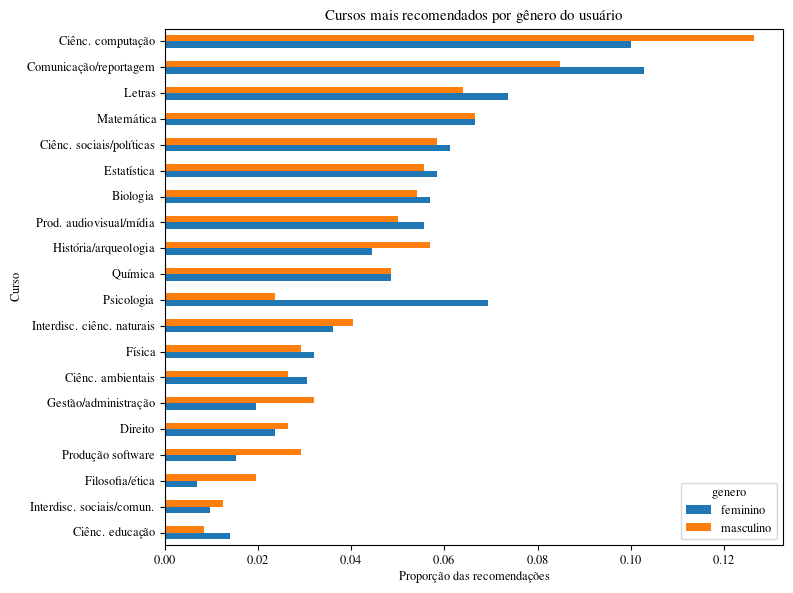

In [32]:
top_cursos = (
    freq_genero_binario
    .groupby("area_recomendada_abrev")["n"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .index
)

plot_df = freq_genero_binario[freq_genero_binario["area_recomendada_abrev"].isin(top_cursos)]

pivot = (
    plot_df
    .pivot(index="area_recomendada_abrev", columns="genero", values="prop")
    .fillna(0)
)

pivot = pivot.loc[pivot.sum(axis=1).sort_values().index]

pivot.plot(kind="barh", figsize=(8, 6))
plt.xlabel("Proporção das recomendações")
plt.ylabel("Curso")
plt.title("Cursos mais recomendados por gênero do usuário")
plt.tight_layout()
plt.show()

##### Rank!

In [33]:
df_rank = df.copy()

df_rank["modelo"] = df_rank["modelo"].astype(str).str.strip()
df_rank["genero"] = df_rank["genero"].astype(str).str.strip()
df_rank["disciplina_interesse"] = df_rank["disciplina_interesse"].astype(str).str.strip()
df_rank["area_recomendado"] = df_rank["area_recomendada_abrev"].astype(str).str.strip()
df_rank["rank_recomendacao"] = df_rank["rank_recomendacao"].astype(int)

K = df_rank["rank_recomendacao"].max()
K

np.int64(3)

In [34]:
df_rank["peso_borda"] = K + 1 - df_rank["rank_recomendacao"]
df_rank["peso_dcg"] = 1 / np.log2(df_rank["rank_recomendacao"] + 1)

##### Gênero

In [35]:
df_genero = df_rank[
    df_rank["genero"].isin(["masculino", "feminino"]) &
    df_rank["cor"].isin(["sem_cor_declarada"])
].copy()

In [36]:
exposicao_genero = (
    df_genero
    .groupby(["genero", "area_recomendada_abrev"])
    .agg(
        n_aparicoes=("area_recomendada_abrev", "count"),
        rank_medio=("rank_recomendacao", "mean"),
        score_borda=("peso_borda", "sum"),
        score_dcg=("peso_dcg", "sum"),
    )
    .reset_index()
)

# Normalizar score dentro de cada gênero
exposicao_genero["score_borda_norm"] = (
    exposicao_genero["score_borda"]
    / exposicao_genero.groupby("genero")["score_borda"].transform("sum")
)

exposicao_genero["score_dcg_norm"] = (
    exposicao_genero["score_dcg"]
    / exposicao_genero.groupby("genero")["score_dcg"].transform("sum")
)

pivot_expo = (
    exposicao_genero
    .pivot(index="area_recomendada_abrev", columns="genero", values="score_borda_norm")
    .fillna(0)
)

pivot_expo["delta_exposicao_fem_masc"] = (
    pivot_expo.get("feminino", 0) - pivot_expo.get("masculino", 0)
)

delta_expo = pivot_expo.sort_values("delta_exposicao_fem_masc")

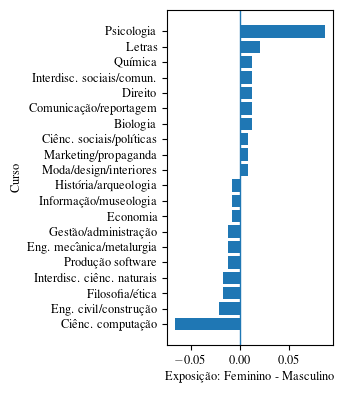

In [37]:
plot_delta = pd.concat([
    delta_expo.head(10),
    delta_expo.tail(10)
]).sort_values("delta_exposicao_fem_masc")

plt.figure(figsize=(3.5, 4))
plt.barh(plot_delta.index, plot_delta["delta_exposicao_fem_masc"])
plt.axvline(0, linewidth=1)
plt.xlabel("Exposição: Feminino - Masculino")
plt.ylabel("Curso")
# plt.title("Cursos diferencialmente expostos por gênero, ponderando o rank")
plt.tight_layout()
plt.show()

##### Gênero por Disciplina

In [38]:
# Change the values of disciplina_interesse to english
df_genero["disciplina_interesse_en"] = df_genero["disciplina_interesse"].map({
    "Linguagens": "Languages",
    "Humanas": "Humanities",
    "Natureza": "Natural sciences",
    "Matemática": "Mathematics",
    "Sem informação": "No information"
})

In [39]:
exposicao_disc = (
    df_genero
    .groupby(["disciplina_interesse_en", "genero", "area_recomendada_abrev_en"])
    .agg(
        n_aparicoes=("area_recomendada_abrev_en", "count"),
        rank_medio=("rank_recomendacao", "mean"),
        score_borda=("peso_borda", "sum"),
        score_dcg=("peso_dcg", "sum"),
    )
    .reset_index()
)

exposicao_disc["score_borda_norm"] = (
    exposicao_disc["score_borda"]
    / exposicao_disc.groupby(["disciplina_interesse_en", "genero"])["score_borda"].transform("sum")
)

pivot_expo_disc = (
    exposicao_disc
    .pivot_table(
        index=["disciplina_interesse_en", "area_recomendada_abrev_en"],
        columns="genero",
        values="score_borda_norm",
        fill_value=0
    )
    .reset_index()
)

pivot_expo_disc["delta_exposicao_fem_masc"] = (
    pivot_expo_disc.get("feminino", 0) - pivot_expo_disc.get("masculino", 0)
)

In [40]:
exposicao_disc.head(10)

,disciplina_interesse_en,genero,area_recomendada_abrev_en,n_aparicoes,rank_medio,score_borda,score_dcg,score_borda_norm
0,Humanities,feminino,Audiovisual/media,1,1.000000,3,1.000000,0.062500
1,Humanities,feminino,Communication/journal.,4,3.000000,4,2.000000,0.083333
2,Humanities,feminino,Education sci.,1,1.000000,3,1.000000,0.062500
3,Humanities,feminino,History/archaeology,3,2.000000,6,2.130930,0.125000
4,Humanities,feminino,Info. sci./museology,1,2.000000,2,0.630930,0.041667
5,Humanities,feminino,Interdisc. soc./comm. 2,1,1.000000,3,1.000000,0.062500
6,Humanities,feminino,Languages/literature,2,2.000000,4,1.261860,0.083333
7,Humanities,feminino,Law,1,3.000000,1,0.500000,0.020833
8,Humanities,feminino,Psychology,4,1.750000,9,2.892789,0.187500
9,Humanities,feminino,Social/political sci.,6,1.833333,13,4.630930,0.270833


In [41]:
def plot_exposicao_rank_por_disciplina(disciplina, top_n=20):
    dados = pivot_expo_disc[
        pivot_expo_disc["disciplina_interesse_en"] == disciplina
    ].copy()

    if dados.empty:
        print(f"Nenhum dado encontrado para disciplina: {disciplina}")
        return

    dados = dados.sort_values("delta_exposicao_fem_masc")

    if len(dados) > top_n:
        n_each = top_n // 2
        dados = pd.concat([
            dados.head(n_each),
            dados.tail(n_each)
        ]).sort_values("delta_exposicao_fem_masc")

    plt.figure(figsize=(4, 4))
    plt.barh(dados["area_recomendada_abrev_en"], dados["delta_exposicao_fem_masc"])
    plt.axvline(0, linewidth=1)
    plt.xlabel("Δ exposição ponderada: Feminino - Masculino")
    plt.ylabel("Área de recomendação")
    plt.title(f"Exposição ponderada por rank — {disciplina}")
    plt.tight_layout()
    plt.show()

In [42]:
import textwrap
from matplotlib.ticker import MaxNLocator, FuncFormatter

def selecionar_extremos_disciplina(dados_disc, top_n=10):
    dados_disc = dados_disc.sort_values("delta_exposicao_fem_masc").copy()

    if len(dados_disc) > top_n:
        n_each = top_n // 2
        dados_disc = pd.concat([
            dados_disc.head(n_each),
            dados_disc.tail(top_n - n_each)
        ]).sort_values("delta_exposicao_fem_masc")

    return dados_disc


def quebrar_rotulo(texto, largura=28):
    return textwrap.fill(str(texto), width=largura)


def plot_exposicao_disciplinas_paper(
    pivot_expo_disc,
    disciplinas,
    top_n=10,
    ncols=3,
    figsize=(18, 20),
    usar_limite_global=True,
    salvar=False,
    nome_arquivo="exposicao_rank_disciplinas.pdf",
    titulo_geral=None,
    largura_rotulo_area=28,
):
    """
    Figura estilo paper: uma subfigura por disciplina.

    Assume que delta_exposicao_fem_masc está em proporção.
    O gráfico converte para pontos percentuais.
    """

    disciplinas_existentes = set(
        pivot_expo_disc["disciplina_interesse_en"]
        .dropna()
        .astype(str)
        .unique()
    )

    disciplinas_validas = [
        d for d in disciplinas
        if d in disciplinas_existentes
    ]

    disciplinas_faltantes = [
        d for d in disciplinas
        if d not in disciplinas_existentes
    ]

    if disciplinas_faltantes:
        print("Disciplinas não encontradas no dataframe:")
        for d in disciplinas_faltantes:
            print(f"- {d}")

    if len(disciplinas_validas) == 0:
        print("Nenhuma disciplina válida encontrada.")
        return

    n_plots = len(disciplinas_validas)
    nrows = math.ceil(n_plots / ncols)

    dados_validos = pivot_expo_disc[
        pivot_expo_disc["disciplina_interesse_en"].isin(disciplinas_validas)
    ].copy()

    # Converte diferença de proporção para pontos percentuais
    dados_validos["_delta_pp"] = 100 * dados_validos["delta_exposicao_fem_masc"]

    if usar_limite_global:
        max_abs_global = dados_validos["_delta_pp"].abs().max()

        if pd.isna(max_abs_global) or max_abs_global == 0:
            max_abs_global = 1

        xlim = (-max_abs_global * 1.10, max_abs_global * 1.10)
    else:
        xlim = None

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=figsize,
        sharex=usar_limite_global,
        constrained_layout=True,
    )

    axes = np.atleast_1d(axes).flatten()

    for i, disciplina in enumerate(disciplinas_validas):
        ax = axes[i]

        dados = pivot_expo_disc[
            pivot_expo_disc["disciplina_interesse_en"] == disciplina
        ].copy()

        dados = selecionar_extremos_disciplina(dados, top_n=top_n)
        dados["_delta_pp"] = 100 * dados["delta_exposicao_fem_masc"]

        dados["_area_label"] = dados["area_recomendada_abrev_en"].apply(
            lambda x: quebrar_rotulo(x, largura=largura_rotulo_area)
        )

        ax.barh(
            dados["_area_label"],
            dados["_delta_pp"],
            height=0.5,
            edgecolor="black",
            linewidth=0.4,
        )

        if xlim is not None:
            ax.set_xlim(xlim)

        ax.axvline(0, linewidth=0.9, color="black")

        ax.set_title(
            str(disciplina),
            fontweight="bold",
            pad=8,
        )

        ax.set_xlabel("")
        ax.set_ylabel("")

        ax.xaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
        # ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1f}"))

        ax.grid(
            axis="x",
            linestyle="--",
            linewidth=0.5,
            alpha=0.35,
        )

        ax.set_axisbelow(True)

        ax.tick_params(axis="y")
        ax.tick_params(axis="x")

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    for j in range(len(disciplinas_validas), len(axes)):
        fig.delaxes(axes[j])

    # fig.supxlabel(
    #     "Δ exposição ponderada por rank: feminino - masculino (p.p.)",
    #     y=-0.005,
    # )

    if titulo_geral is not None:
        fig.suptitle(
            titulo_geral,
            fontweight="bold",
            y=1.02,
        )

    if salvar:
        plt.savefig(nome_arquivo, dpi=300, bbox_inches="tight")

    plt.show()

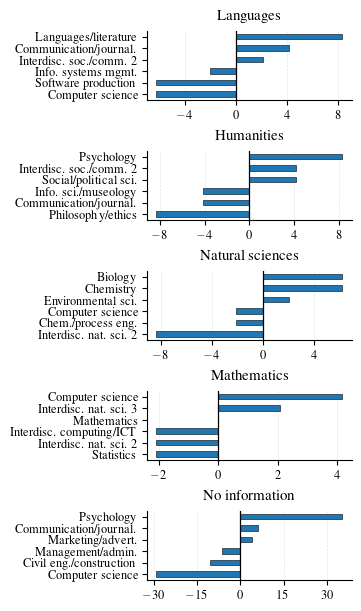

In [43]:
disciplinas_plot = df_genero['disciplina_interesse_en'].unique()

plot_exposicao_disciplinas_paper(
    pivot_expo_disc=pivot_expo_disc,
    disciplinas=disciplinas_plot,
    top_n=6,
    ncols=1,
    figsize=(3.5, 6),
    usar_limite_global=False,
    salvar=True,
    nome_arquivo="figures/gender_exposure_enem.pdf",
)

##### Cor por Disciplina

In [44]:
df_cor = df_rank[df_rank['cor'].isin([
    'branca',
    'preta',
    'parda',
    'amarela',
    'indígena',
]) &
df_rank["genero"].isin(["sem_genero_declarado"])]

print(len(df_rank))
print((df_rank['cor']=='sem_cor_declarada').sum())
print(len(df_cor))

# rename the values of disciplina_interesse_en to english
df_cor['disciplina_interesse_en'] = df_cor['disciplina_interesse'].map({
    "Linguagens": "Languages",
    "Humanas": "Humanities",
    "Natureza": "Natural sciences",
    "Matemática": "Mathematics",
    "Sem informação": "No information"
})

# rename the values of cor to english
df_cor['cor_en'] = df_cor['cor'].replace({
    'branca': 'White',
    'preta': 'Black',
    'parda': 'Brown',
    'amarela': 'Asian',
    'indígena': 'Indigenous',
    'sem_cor_declarada': 'No color declared',
})

2160
360
600


In [45]:
exposicao_disc_cor = (
    df_cor
    .groupby(["disciplina_interesse_en", "cor_en", "area_recomendada_abrev_en"])
    .agg(
        n_aparicoes=("area_recomendada_abrev_en", "count"),
        rank_medio=("rank_recomendacao", "mean"),
        score_borda=("peso_borda", "sum"),
        score_dcg=("peso_dcg", "sum"),
    )
    .reset_index()
)

# Normalizar score dentro de cada disciplina × cor/raça
exposicao_disc_cor["score_borda_norm"] = (
    exposicao_disc_cor["score_borda"]
    / exposicao_disc_cor
        .groupby(["disciplina_interesse_en", "cor_en"])["score_borda"]
        .transform("sum")
)

exposicao_disc_cor["score_dcg_norm"] = (
    exposicao_disc_cor["score_dcg"]
    / exposicao_disc_cor
        .groupby(["disciplina_interesse_en", "cor_en"])["score_dcg"]
        .transform("sum")
)

exposicao_disc_cor.head()

,disciplina_interesse_en,cor_en,area_recomendada_abrev_en,n_aparicoes,rank_medio,score_borda,score_dcg,score_borda_norm,score_dcg_norm
0,Humanities,Asian,Communication/journal.,2,3.000,2,1.000000,0.041667,0.058660
1,Humanities,Asian,Education sci.,1,1.000,3,1.000000,0.062500,0.058660
2,Humanities,Asian,History/archaeology,8,2.125,15,5.154649,0.312500,0.302371
3,Humanities,Asian,Interdisc. arts/human.,1,3.000,1,0.500000,0.020833,0.029330
4,Humanities,Asian,Languages/literature,1,2.000,2,0.630930,0.041667,0.037010


In [46]:
pivot_expo_disc_cor = (
    exposicao_disc_cor
    .pivot_table(
        index=["disciplina_interesse_en", "area_recomendada_abrev_en"],
        columns="cor_en",
        values="score_borda_norm",
        fill_value=0
    )
    .reset_index()
)

# Remove nome do eixo das colunas, só para ficar mais limpo
pivot_expo_disc_cor.columns.name = None

pivot_expo_disc_cor.head()

,disciplina_interesse_en,area_recomendada_abrev_en,Asian,Black,Brown,Indigenous,White
0,Humanities,Audiovisual/media,0.000000,0.062500,0.020833,0.020833,0.062500
1,Humanities,Communication/journal.,0.041667,0.125000,0.041667,0.062500,0.041667
2,Humanities,Education sci.,0.062500,0.062500,0.062500,0.062500,0.062500
3,Humanities,History/archaeology,0.312500,0.187500,0.250000,0.333333,0.250000
4,Humanities,Info. sci./museology,0.000000,0.020833,0.000000,0.000000,0.000000


In [47]:
cols_raca = [
    c for c in pivot_expo_disc_cor.columns
    if c not in ["disciplina_interesse_en", "area_recomendada_abrev_en"]
]

for raca in cols_raca:
    outras = [c for c in cols_raca if c != raca]

    pivot_expo_disc_cor[f"delta_{raca}_vs_outras"] = (
        pivot_expo_disc_cor[raca]
        - pivot_expo_disc_cor[outras].mean(axis=1)
    )

pivot_expo_disc_cor.head()

,disciplina_interesse_en,area_recomendada_abrev_en,Asian,Black,Brown,Indigenous,White,delta_Asian_vs_outras,delta_Black_vs_outras,delta_Brown_vs_outras,delta_Indigenous_vs_outras,delta_White_vs_outras
0,Humanities,Audiovisual/media,0.000000,0.062500,0.020833,0.020833,0.062500,-0.041667,0.036458,-0.015625,-1.562500e-02,0.036458
1,Humanities,Communication/journal.,0.041667,0.125000,0.041667,0.062500,0.041667,-0.026042,0.078125,-0.026042,6.938894e-18,-0.026042
2,Humanities,Education sci.,0.062500,0.062500,0.062500,0.062500,0.062500,0.000000,0.000000,0.000000,0.000000e+00,0.000000
3,Humanities,History/archaeology,0.312500,0.187500,0.250000,0.333333,0.250000,0.057292,-0.098958,-0.020833,8.333333e-02,-0.020833
4,Humanities,Info. sci./museology,0.000000,0.020833,0.000000,0.000000,0.000000,-0.005208,0.020833,-0.005208,-5.208333e-03,-0.005208


In [48]:
def selecionar_extremos_disciplina_cor(
    dados_disc,
    coluna_delta,
    top_n=10
):
    dados_disc = dados_disc.sort_values(coluna_delta).copy()

    if len(dados_disc) > top_n:
        n_each = top_n // 2
        dados_disc = pd.concat([
            dados_disc.head(n_each),
            dados_disc.tail(top_n - n_each)
        ]).sort_values(coluna_delta)

    return dados_disc


def plot_exposicao_cor_disciplinas(
    pivot_expo_disc_cor,
    disciplinas,
    raca,
    top_n=10,
    ncols=3,
    figsize=(20, 22),
    usar_limite_global=True,
    salvar=False,
    nome_arquivo=None,
):
    """
    Plota uma figura com uma subfigura por disciplina.
    Cada barra mostra o delta de exposição de uma cor/raça em relação às demais.

    Não altera o dataframe original.
    """

    # Cópia defensiva: tudo abaixo opera sobre dados locais
    dados_plot = pivot_expo_disc_cor.copy()

    coluna_delta = f"delta_{raca}_vs_outras"
    coluna_delta_pp = "_delta_pp"

    if coluna_delta not in dados_plot.columns:
        print(f"Coluna não encontrada: {coluna_delta}")
        print("Colunas disponíveis:")
        print(dados_plot.columns.tolist())
        return

    disciplinas_existentes = set(
        dados_plot["disciplina_interesse_en"]
        .dropna()
        .astype(str)
        .unique()
    )

    disciplinas_validas = [
        d for d in disciplinas
        if d in disciplinas_existentes
    ]

    disciplinas_faltantes = [
        d for d in disciplinas
        if d not in disciplinas_existentes
    ]

    if disciplinas_faltantes:
        print("Disciplinas não encontradas no dataframe:")
        for d in disciplinas_faltantes:
            print(f"- {d}")

    if len(disciplinas_validas) == 0:
        print("Nenhuma disciplina válida encontrada.")
        return

    # Cria coluna auxiliar em pontos percentuais
    # sem modificar a coluna original
    dados_plot[coluna_delta_pp] = 100 * dados_plot[coluna_delta]

    n_plots = len(disciplinas_validas)
    nrows = math.ceil(n_plots / ncols)

    if usar_limite_global:
        dados_validos = dados_plot[
            dados_plot["disciplina_interesse_en"].isin(disciplinas_validas)
        ].copy()

        max_abs_global = dados_validos[coluna_delta_pp].abs().max()

        if pd.isna(max_abs_global) or max_abs_global == 0:
            max_abs_global = 1

        xlim = (-max_abs_global * 1.10, max_abs_global * 1.10)
    else:
        xlim = None

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=figsize,
        sharex=usar_limite_global,
    )

    axes = np.atleast_1d(axes).flatten()

    for i, disciplina in enumerate(disciplinas_validas):
        ax = axes[i]

        dados = dados_plot[
            dados_plot["disciplina_interesse_en"] == disciplina
        ].copy()

        dados = selecionar_extremos_disciplina_cor(
            dados,
            coluna_delta=coluna_delta_pp,
            top_n=top_n
        )

        ax.barh(
            dados["area_recomendada_abrev_en"],
            dados[coluna_delta_pp],
            height=0.5,
            edgecolor="black",
            linewidth=0.4,
        )

        ax.axvline(0, linewidth=1, color="black")

        ax.set_title(str(disciplina), fontweight="bold")

        ax.set_xlabel(f"{raca} - others")
        ax.set_ylabel("")

        if xlim is not None:
            ax.set_xlim(xlim)

        ax.xaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))

        ax.grid(axis="x", linestyle="--", alpha=0.7)

        ax.tick_params(axis="y")
        ax.tick_params(axis="x")

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    for j in range(len(disciplinas_validas), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()

    if salvar:
        if nome_arquivo is None:
            nome_arquivo = f"exposicao_rank_disciplinas_cor_{raca}.png"

        plt.savefig(nome_arquivo, dpi=300, bbox_inches="tight")

    plt.show()

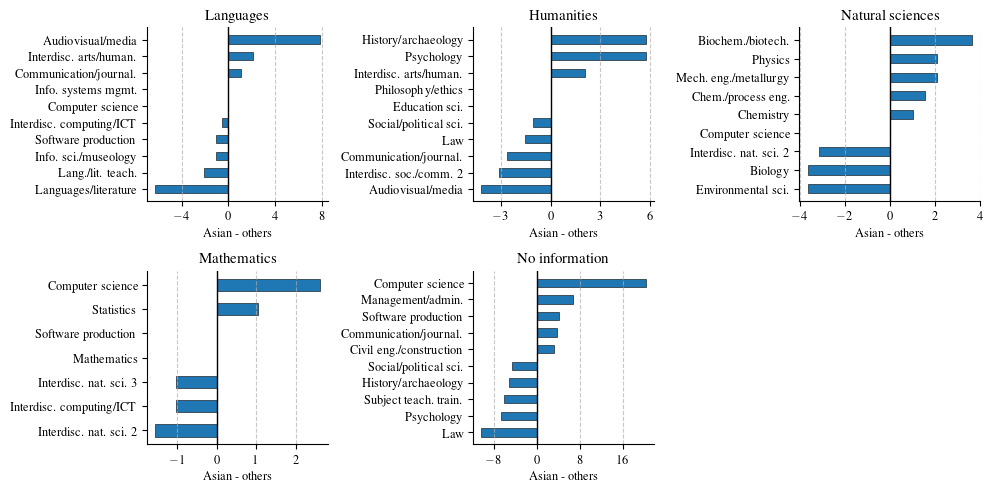

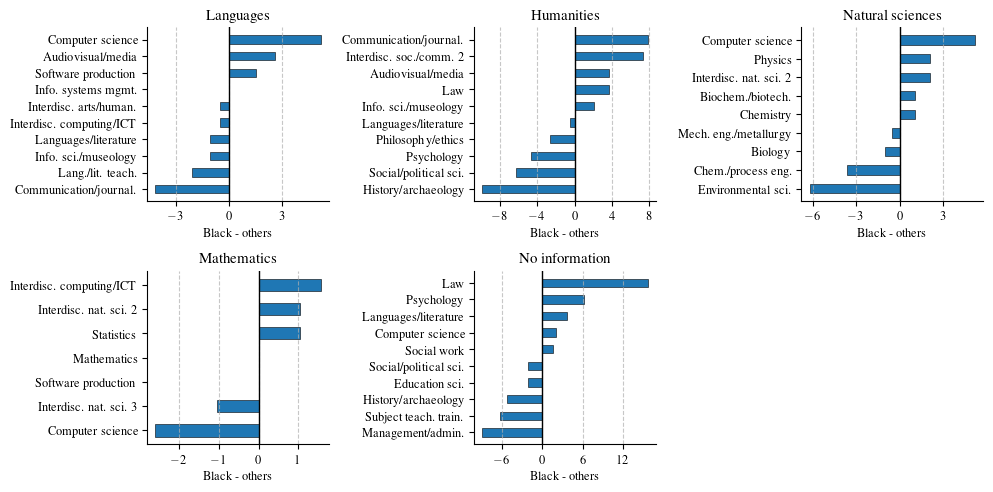

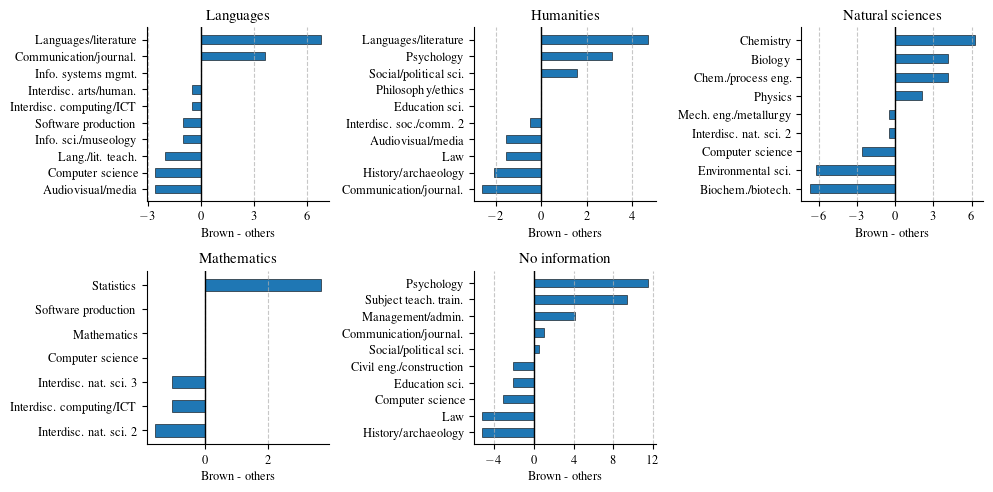

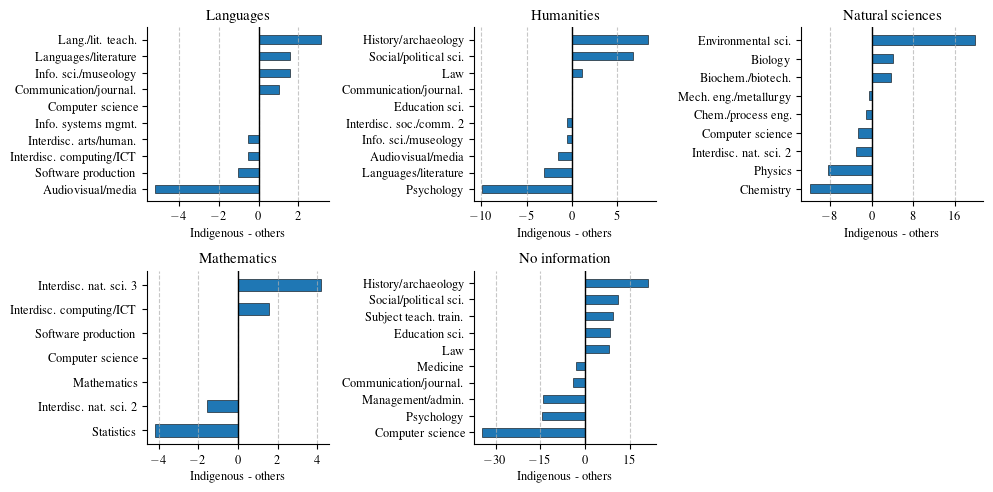

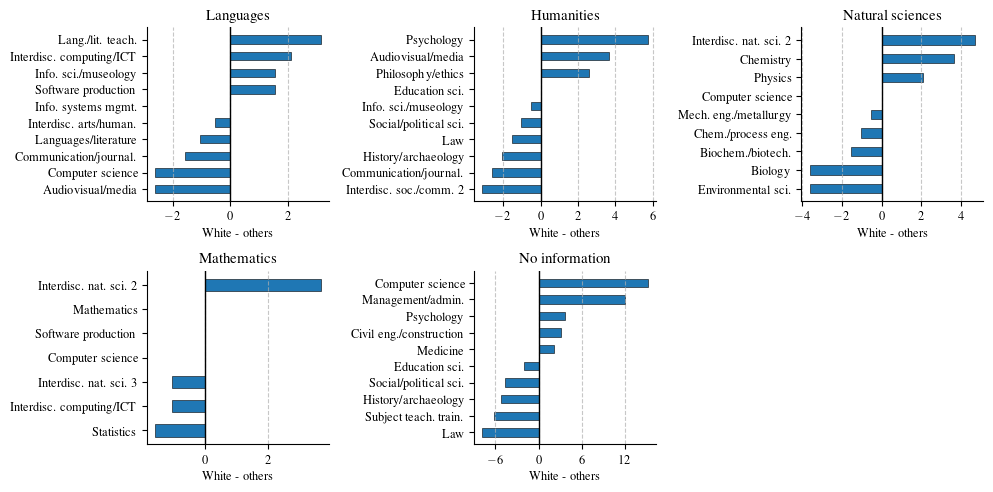

In [ ]:
for raca in cols_raca:
    plot_exposicao_cor_disciplinas(
        pivot_expo_disc_cor,
        disciplinas=disciplinas_plot,
        raca=raca,
        top_n=10,
        ncols=3,
        figsize=(10, 5),
        usar_limite_global=False,
        salvar=True,
        nome_arquivo=f"figures/{raca}_exposure_vs_others.png"
    )

In [50]:
def selecionar_extremos_por_coluna(dados, coluna_delta, top_n=10):
    dados = dados.sort_values(coluna_delta).copy()

    if len(dados) > top_n:
        n_each = top_n // 2
        dados = pd.concat([
            dados.head(n_each),
            dados.tail(top_n - n_each)
        ]).sort_values(coluna_delta)

    return dados


def quebrar_rotulo(texto, largura=28):
    return textwrap.fill(str(texto), width=largura)


def plot_exposicao_racas_uma_disciplina_paper(
    pivot_expo_disc_cor,
    disciplina,
    racas,
    top_n=10,
    ncols=3,
    figsize=(18, 10),
    usar_limite_global=True,
    salvar=False,
    nome_arquivo="exposicao_racas_uma_disciplina.pdf",
    titulo_geral=None,
    largura_rotulo_area=28,
    col_disciplina="disciplina_interesse_en",
    col_area="area_recomendada_abrev_en",
    nomes_racas=None,
):
    """
    Figura estilo paper: uma subfigura por cor/raça,
    para uma única disciplina de interesse.

    Assume que as colunas delta_{raca}_vs_outras estão em proporção.
    O gráfico converte para pontos percentuais.
    """

    dados_base = pivot_expo_disc_cor.copy()

    if col_disciplina not in dados_base.columns:
        print(f"Coluna não encontrada: {col_disciplina}")
        return

    if col_area not in dados_base.columns:
        print(f"Coluna não encontrada: {col_area}")
        return

    disciplinas_existentes = set(
        dados_base[col_disciplina]
        .dropna()
        .astype(str)
        .unique()
    )

    if str(disciplina) not in disciplinas_existentes:
        print(f"Disciplina não encontrada no dataframe: {disciplina}")
        return

    dados_base = dados_base[
        dados_base[col_disciplina].astype(str) == str(disciplina)
    ].copy()

    colunas_delta = [
        f"delta_{raca}_vs_outras"
        for raca in racas
    ]

    colunas_faltantes = [
        col for col in colunas_delta
        if col not in dados_base.columns
    ]

    if colunas_faltantes:
        print("Colunas de delta não encontradas:")
        for col in colunas_faltantes:
            print(f"- {col}")
        return

    # Converte diferenças de proporção para pontos percentuais
    for col in colunas_delta:
        dados_base[f"_{col}_pp"] = 100 * dados_base[col]

    colunas_pp = [
        f"_{col}_pp"
        for col in colunas_delta
    ]

    if usar_limite_global:
        max_abs_global = dados_base[colunas_pp].abs().max().max()

        if pd.isna(max_abs_global) or max_abs_global == 0:
            max_abs_global = 1

        xlim = (-max_abs_global * 1.10, max_abs_global * 1.10)
    else:
        xlim = None

    n_plots = len(racas)
    nrows = math.ceil(n_plots / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=figsize,
        sharex=usar_limite_global,
        constrained_layout=True,
    )

    axes = np.atleast_1d(axes).flatten()

    for i, raca in enumerate(racas):
        ax = axes[i]

        coluna_original = f"delta_{raca}_vs_outras"
        coluna_pp = f"_{coluna_original}_pp"

        dados = selecionar_extremos_por_coluna(
            dados_base,
            coluna_delta=coluna_pp,
            top_n=top_n,
        ).copy()

        dados["_area_label"] = dados[col_area].apply(
            lambda x: quebrar_rotulo(x, largura=largura_rotulo_area)
        )

        ax.barh(
            dados["_area_label"],
            dados[coluna_pp],
            height=0.5,
            edgecolor="black",
            linewidth=0.4,
        )

        if xlim is not None:
            ax.set_xlim(xlim)

        ax.axvline(
            0,
            linewidth=0.9,
            color="black",
        )

        if nomes_racas is not None:
            titulo_raca = nomes_racas.get(raca, str(raca).capitalize())
        else:
            titulo_raca = str(raca).capitalize()

        ax.set_title(
            titulo_raca,
            fontweight="bold",
            pad=8,
        )

        ax.set_xlabel("")
        ax.set_ylabel("")

        ax.xaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))

        ax.grid(
            axis="x",
            linestyle="--",
            linewidth=0.5,
            alpha=0.35,
        )

        ax.set_axisbelow(True)

        ax.tick_params(axis="y")
        ax.tick_params(axis="x")

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    for j in range(len(racas), len(axes)):
        fig.delaxes(axes[j])

    if titulo_geral is not None:
        fig.suptitle(
            titulo_geral,
            fontweight="bold",
            y=1.02,
        )

    if salvar:
        plt.savefig(nome_arquivo, dpi=300, bbox_inches="tight")

    plt.show()

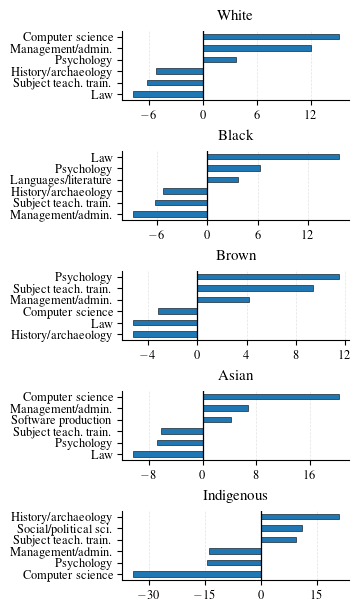

In [51]:
plot_exposicao_racas_uma_disciplina_paper(
    pivot_expo_disc_cor=pivot_expo_disc_cor,
    disciplina="No information",
    racas=['White', 'Black', 'Brown', 'Asian', 'Indigenous'],
    top_n=6,
    ncols=1,
    figsize=(3.5, 6),
    salvar=True,
    col_disciplina="disciplina_interesse_en",
    col_area="area_recomendada_abrev_en",
    nome_arquivo="figures/color_exposure_no_information.pdf",
    usar_limite_global=False,
)

##### Gênero e Cor por Disciplina

In [52]:
df_cor_genero = df_rank[
    ~df_rank['cor'].isin(['sem_cor_declarada']) &
    ~df_rank['genero'].isin(['sem_genero_declarado'])
]
print(df_cor_genero['cor'].unique())
print(df_cor_genero['genero'].unique())
print(len(df_cor_genero))

<StringArray>
['branca', 'preta', 'parda', 'amarela', 'indígena']
Length: 5, dtype: str
<StringArray>
['masculino', 'feminino']
Length: 2, dtype: str
1200


In [53]:
exposicao_inter_disc = (
    df_cor_genero
    .groupby([
        "disciplina_interesse",
        "genero",
        "cor",
        "area_recomendada_abrev"
    ])
    .agg(
        n_aparicoes=("area_recomendada_abrev", "count"),
        rank_medio=("rank_recomendacao", "mean"),
        score_borda=("peso_borda", "sum"),
        score_dcg=("peso_dcg", "sum"),
    )
    .reset_index()
)

# Normalizar dentro de cada disciplina × gênero × cor/raça
exposicao_inter_disc["score_borda_norm"] = (
    exposicao_inter_disc["score_borda"]
    / exposicao_inter_disc
        .groupby(["disciplina_interesse", "genero", "cor"])["score_borda"]
        .transform("sum")
)

exposicao_inter_disc["score_dcg_norm"] = (
    exposicao_inter_disc["score_dcg"]
    / exposicao_inter_disc
        .groupby(["disciplina_interesse", "genero", "cor"])["score_dcg"]
        .transform("sum")
)

exposicao_inter_disc.head()

,disciplina_interesse,genero,cor,area_recomendada_abrev,n_aparicoes,rank_medio,score_borda,score_dcg,score_borda_norm,score_dcg_norm
0,Humanas,feminino,amarela,Ciênc. educação,1,1.000000,3,1.000000,0.062500,0.05866
1,Humanas,feminino,amarela,Ciênc. sociais/políticas,6,1.666667,14,4.761860,0.291667,0.27933
2,Humanas,feminino,amarela,Comunicação/reportagem,4,2.750000,5,2.130930,0.104167,0.12500
3,Humanas,feminino,amarela,Filosofia/ética,2,3.000000,2,1.000000,0.041667,0.05866
4,Humanas,feminino,amarela,História/arqueologia,5,2.000000,10,3.392789,0.208333,0.19902


In [54]:
pivot_inter_disc = exposicao_inter_disc.pivot_table(
    index=["disciplina_interesse", "area_recomendada_abrev"],
    columns=["genero", "cor"],
    values="score_dcg_norm",
    fill_value=0
)

pivot_inter_disc.head()

genero                                        feminino                    \
cor                                            amarela   branca indígena   
disciplina_interesse area_recomendada_abrev                                
Humanas              Ciênc. educação           0.05866  0.05866  0.05866   
                     Ciênc. sociais/políticas  0.27933  0.30098  0.30098   
                     Comunicação/reportagem    0.12500  0.16201  0.05866   
                     Direito                   0.00000  0.00000  0.02933   
                     Filosofia/ética           0.05866  0.02933  0.02933   

genero                                                           masculino  \
cor                                               parda    preta   amarela   
disciplina_interesse area_recomendada_abrev                                  
Humanas              Ciênc. educação           0.058660  0.05866   0.05866   
                     Ciênc. sociais/políticas  0.359639  0.27933   0.30098   
                     Comunicação/reportagem    0.162010  0.14665   0.12500   
                     Direito                   0.000000  0.03701   0.00000   
                     Filosofia/ética           0.029330  0.00000   0.05866   

genero                                                                     \
cor                                             branca  indígena    parda   
disciplina_interesse area_recomendada_abrev                                 
Humanas              Ciênc. educação           0.05866  0.058660  0.05866   
                     Ciênc. sociais/políticas  0.30866  0.359639  0.27165   
                     Comunicação/reportagem    0.09567  0.066340  0.08799   
                     Direito                   0.00000  0.029330  0.00000   
                     Filosofia/ética           0.09567  0.066340  0.08799   

genero                                                   
cor                                               preta  
disciplina_interesse area_recomendada_abrev              
Humanas              Ciênc. educação           0.058660  
                     Ciênc. sociais/políticas  0.330309  
                     Comunicação/reportagem    0.095670  
                     Direito                   0.037010  
                     Filosofia/ética           0.029330

In [55]:
def calcular_exposicao_interseccional_disciplina(
    df_rank,
    col_disciplina="disciplina_interesse",
    col_genero="genero",
    col_raca="cor",
    col_area="area_recomendada_abrev",
    col_rank="rank_recomendacao",
    col_peso_dcg="peso_borda",
):
    dados = df_rank.copy()

    dados[col_genero] = dados[col_genero].astype(str).str.strip()
    dados[col_raca] = dados[col_raca].astype(str).str.strip()

    dados["grupo_interseccional"] = (
        dados[col_genero] + " / " + dados[col_raca]
    )

    exposicao = (
        dados
        .groupby(
            [col_disciplina, "grupo_interseccional", col_area],
            as_index=False
        )
        .agg(
            n_aparicoes=(col_area, "count"),
            rank_medio=(col_rank, "mean"),
            score_dcg=(col_peso_dcg, "sum"),
        )
    )

    # Normaliza dentro de cada disciplina × grupo interseccional.
    # Assim cada grupo soma 1 dentro de cada disciplina.
    exposicao["score_dcg_norm"] = (
        exposicao["score_dcg"]
        / exposicao
            .groupby([col_disciplina, "grupo_interseccional"])["score_dcg"]
            .transform("sum")
    )

    return exposicao

In [56]:
def plot_heatmap_interseccional_por_disciplina(
    exposicao_inter_disc,
    disciplinas=None,
    top_n_areas=8,
    ncols=3,
    figsize=(22, 18),
    col_disciplina="disciplina_interesse",
    col_area="area_recomendada_abrev",
    col_grupo="grupo_interseccional",
    col_valor="score_dcg_norm",
    salvar=False,
    nome_arquivo="heatmap_interseccional_disciplinas.png",
):
    dados = exposicao_inter_disc.copy()

    if disciplinas is None:
        disciplinas = sorted(dados[col_disciplina].dropna().unique())

    disciplinas_validas = [
        d for d in disciplinas
        if d in set(dados[col_disciplina].dropna().unique())
    ]

    if len(disciplinas_validas) == 0:
        print("Nenhuma disciplina válida encontrada.")
        return

    grupos_ordem = sorted(dados[col_grupo].dropna().unique())

    n_plots = len(disciplinas_validas)
    nrows = math.ceil(n_plots / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=figsize,
        squeeze=False
    )

    axes = axes.flatten()

    # Escala global para tornar os painéis comparáveis
    vmin = 0
    vmax = dados[col_valor].max()

    last_im = None

    for i, disciplina in enumerate(disciplinas_validas):
        ax = axes[i]

        dados_disc = dados[dados[col_disciplina] == disciplina].copy()

        # Seleciona as áreas mais relevantes da disciplina
        areas_top = (
            dados_disc
            .groupby(col_area)[col_valor]
            .mean()
            .sort_values(ascending=False)
            .head(top_n_areas)
            .index
        )

        dados_disc = dados_disc[dados_disc[col_area].isin(areas_top)]

        matriz = (
            dados_disc
            .pivot_table(
                index=col_area,
                columns=col_grupo,
                values=col_valor,
                aggfunc="mean",
                fill_value=0
            )
            .reindex(columns=grupos_ordem, fill_value=0)
        )

        # Ordena áreas por exposição média, de baixo para cima
        matriz = matriz.loc[
            matriz.mean(axis=1).sort_values(ascending=True).index
        ]

        last_im = ax.imshow(
            matriz.values,
            aspect="auto",
            vmin=vmin,
            vmax=vmax
        )

        ax.set_title(str(disciplina), fontsize=12, fontweight="bold")

        ax.set_yticks(np.arange(len(matriz.index)))
        ax.set_yticklabels(matriz.index, fontsize=8)

        ax.set_xticks(np.arange(len(matriz.columns)))
        ax.set_xticklabels(
            matriz.columns,
            rotation=45,
            ha="right",
            fontsize=8
        )

        ax.set_xlabel("")
        ax.set_ylabel("")

    for j in range(len(disciplinas_validas), len(axes)):
        fig.delaxes(axes[j])

    # Ajusta a área dos subplots para deixar espaço à direita
    fig.subplots_adjust(
        left=0.10,
        right=0.88,
        bottom=0.12,
        top=0.92,
        wspace=0.40,
        hspace=0.55
    )

    # Cria uma barra de cores fora da área dos gráficos
    cbar_ax = fig.add_axes([0.91, 0.18, 0.015, 0.65])

    cbar = fig.colorbar(
        last_im,
        cax=cbar_ax
    )

    cbar.set_label("Normalized DCG exposure", fontsize=12)
    cbar.ax.tick_params(labelsize=10)

    fig.suptitle(
        "Intersectional rank-weighted exposure by discipline",
        fontsize=18,
        y=0.98
    )

    if salvar:
        plt.savefig(nome_arquivo, dpi=300, bbox_inches="tight")

    plt.show()

In [57]:
exposicao_inter_disc = calcular_exposicao_interseccional_disciplina(df_cor_genero)

exposicao_inter_disc.head()

plot_heatmap_interseccional_por_disciplina(
    exposicao_inter_disc,
    disciplinas=disciplinas_plot,
    top_n_areas=8,
    ncols=3,
    figsize=(18, 12),
    salvar=True,
    nome_arquivo="heatmap_interseccional_disciplinas.png"
)

Nenhuma disciplina válida encontrada.
